# Amazon Product Review Sentiment Analysis using Machine Learning

## Project Overview

In this project, we'll build a machine learning model to identify whether an Amazon product review expresses a positive or negative sentiment. The dataset will be explored, cleaned, and preprocessed before training the model. Finally, we'll evaluate its performance and use it to predict the sentiment of new reviews.

## Mini Project 2

## Objective

The main objective of this project is to classify Amazon product reviews as positive or negative using Natural Language Processing (NLP) and Machine Learning.

To achieve this, we'll explore the dataset, clean and preprocess the review text, convert it into numerical features using TF-IDF, train a machine learning model, and evaluate its performance on unseen reviews.

---




## Import Required Libraries



In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import string

import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Load Dataset

In this step, the dataset is loaded into a Pandas DataFrame so it can be explored, cleaned, and prepared for model training.

In [2]:
reviews_data = pd.read_csv(
    "Reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

print("Dataset Loaded Successfully!")
print(reviews_data.shape)
reviews_data.columns

Dataset Loaded Successfully!
(23721, 10)


Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

# Exploratory Data Analysis (EDA)

Before building the sentiment analysis model, let's explore the dataset to understand its structure and identify any issues such as missing values or duplicate records.

## 1. Display First 5 Records

Let's look at the first five rows to get familiar with the dataset and see what information it contains.

In [3]:
print("=" * 60)
print("FIRST 5 RECORDS")
print("=" * 60)

reviews_data.head()

FIRST 5 RECORDS


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


 2. Display Last 5 Records

Now let's look at the last five rows to get a complete view of the dataset and make sure it has been loaded correctly.

In [4]:
print("=" * 60)
print("LAST 5 RECORDS")
print("=" * 60)

reviews_data.tail()

LAST 5 RECORDS


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
23716,23717,B0013NUGDE,A1V7ZYRVRGT9F5,"C. Gallamore ""Weight Watcher Winner""",1,1,5,1271376000,Awesome,These Pop Chips are incredible. They taste so ...
23717,23718,B0013NUGDE,A27DYCAP844HOK,"B. Greer ""Flo Gro""",1,1,4,1271203200,Love 'em,I love these salt and pepper flavored Popchips...
23718,23719,B0013NUGDE,A3FF3R1V94EPN4,troys98,1,1,5,1271203200,Pop Chips are awesome,Taste is similar to regular potato chips but w...
23719,23720,B0013NUGDE,A2MG3HG6VSII0O,S. Bradford,1,1,5,1271030400,DELISH!!,These chips are absolutely incredible!!! They...
23720,23721,B0013NUGDE,AGKJOW98X5KGB,Mommy of one almost-perfect boy,1,1,5,1270166400,Delicious.,"Wow, I'm impressed. These are delicious. They ..."


3. Dataset Shape

Let's check the shape of the dataset to see how many rows and columns it contains.

In [5]:
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print(reviews_data.shape)

DATASET SHAPE
(23721, 10)


4. Column Names

Let's display the column names to understand what information is available in the dataset before starting the analysis.

In [6]:
print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)

print(reviews_data.columns)

COLUMN NAMES
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


 5. Dataset Information

Let's check the dataset information to understand the data types of each column and identify any missing values.

In [7]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

reviews_data.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23721 entries, 0 to 23720
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      23721 non-null  int64 
 1   ProductId               23721 non-null  object
 2   UserId                  23721 non-null  object
 3   ProfileName             23720 non-null  object
 4   HelpfulnessNumerator    23721 non-null  int64 
 5   HelpfulnessDenominator  23721 non-null  int64 
 6   Score                   23721 non-null  int64 
 7   Time                    23721 non-null  int64 
 8   Summary                 23721 non-null  object
 9   Text                    23721 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.8+ MB


6. Statistical Summary

Let's look at the summary statistics of the numerical columns to get a better understanding of the data, including the average, minimum, maximum, and spread of the values.

In [8]:
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

reviews_data.describe()

STATISTICAL SUMMARY


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,23721.000000,23721.000000,23721.000000,23721.000000,2.372100e+04
mean,11861.000000,1.574301,2.033810,4.142785,1.294203e+09
std,6847.807204,5.451570,6.094613,1.315772,4.727833e+07
min,1.000000,0.000000,0.000000,1.000000,9.617184e+08
25%,5931.000000,0.000000,0.000000,4.000000,1.267920e+09
50%,11861.000000,0.000000,1.000000,5.000000,1.308096e+09
75%,17791.000000,1.000000,2.000000,5.000000,1.329696e+09
max,23721.000000,202.000000,219.000000,5.000000,1.351210e+09


 7. Missing Values

Let's check if there are any missing values in the dataset. Identifying missing data helps us decide whether any preprocessing is needed before training the model.

In [9]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

reviews_data.isnull().sum()

MISSING VALUES


,0
Id,0
ProductId,0
UserId,0
ProfileName,1
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


8. Duplicate Records

Before moving ahead, let's check if the dataset contains any duplicate records. If duplicates are found, they can be removed to improve data quality.

In [10]:
print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

print(reviews_data.duplicated().sum())

DUPLICATE RECORDS
0


9. Review Score Distribution

Let's visualize the distribution of review scores to see how the ratings are spread across the dataset. This also helps us identify whether some ratings appear more frequently than others.

In [11]:
print("=" * 60)
print("REVIEW SCORE DISTRIBUTION")
print("=" * 60)

print(reviews_data["Score"].value_counts().sort_index())

REVIEW SCORE DISTRIBUTION
Score
1     2149
2     1378
3     2053
4     3498
5    14643
Name: count, dtype: int64


10. Visualize Review Score Distribution

Let's create a bar chart to see how the review scores are distributed across different ratings.

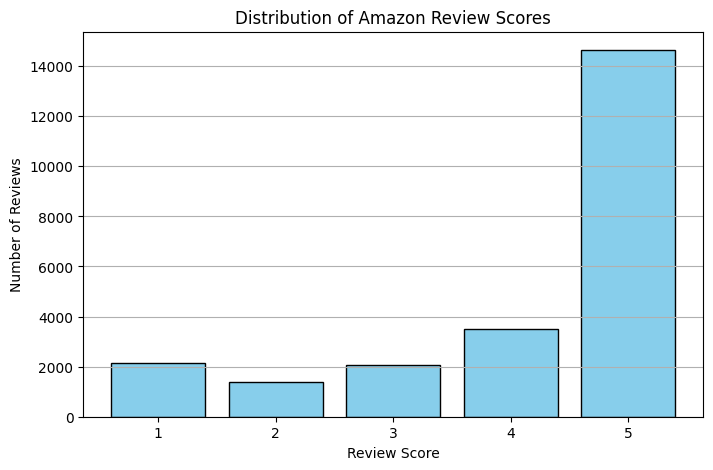

In [12]:
score_counts = reviews_data["Score"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    score_counts.index.astype(str),
    score_counts.values,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Amazon Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.grid(axis="y")

plt.show()

# Data Cleaning

Before training the model, the dataset needs to be cleaned. In this step, we'll keep only the required columns, handle missing values, and prepare the data for sentiment analysis.

1. Select Required Columns

The dataset contains several columns, but only the `Score` and `Text` columns are needed for this project. These columns are selected for the next preprocessing steps.

In [13]:
reviews_data = reviews_data[["Score", "Text"]]

reviews_data.head()

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...


2. Check Missing Values

Let's check whether there are any missing values in the selected columns. If any are found, they can be handled before moving on to the next step.

In [14]:
print(reviews_data.isnull().sum())

Score    0
Text     0
dtype: int64


 3. Remove Missing Values

If any missing values are found, those rows are removed so the dataset is ready for text preprocessing and model training.

In [15]:
reviews_data = reviews_data.dropna()

print("Dataset Shape After Removing Missing Values:")
print(reviews_data.shape)

Dataset Shape After Removing Missing Values:
(23721, 2)


4. Remove Duplicate Reviews

Let's remove any duplicate reviews so that each review is used only once during model training.

In [16]:
reviews_data = reviews_data.drop_duplicates()

print("Dataset Shape After Removing Duplicate Reviews:")
print(reviews_data.shape)

Dataset Shape After Removing Duplicate Reviews:
(22924, 2)


5. Random Sampling of Reviews

The original dataset is very large, so a random sample of 50,000 reviews is selected. This helps reduce processing time while still providing enough data to train and evaluate the sentiment analysis model.

In [17]:
reviews_data = reviews_data.sample(
    n=len(reviews_data),
    random_state=42
)

print("Dataset Shape After Sampling:")
print(reviews_data.shape)

Dataset Shape After Sampling:
(22924, 2)


6. Verify the Sampled Dataset

Let's look at the first five rows of the sampled dataset to make sure the sampling process worked as expected.

In [18]:
reviews_data.head()

,Score,Text
6316,5,The Maxwell House International Coffee - Vanil...
19874,5,Now this is the way everyone should drink coff...
1638,5,A dream for those on Weight Watchers who love ...
4026,5,I have had to change my diet and now have bett...
260,5,"These are healthy and my mixed Llasa, Tibetan ..."


## Create Sentiment Labels

The review scores are converted into two sentiment categories for binary classification. Reviews with ratings of **4** and **5** are labeled as **Positive**, while reviews with ratings of **1** and **2** are labeled as **Negative**. Reviews with a rating of **3** are treated as neutral and are removed from the dataset.

1. Remove Neutral Reviews

Reviews with a rating of **3** are removed because they do not clearly indicate either a positive or a negative opinion. Keeping only positive and negative reviews makes the classification task more straightforward.

In [19]:
# Remove reviews with rating 3

reviews_data = reviews_data[reviews_data["Score"] != 3]

print("Dataset Shape After Removing Neutral Reviews:")
print(reviews_data.shape)

Dataset Shape After Removing Neutral Reviews:
(20961, 2)


 2. Create Sentiment Labels

The review ratings are converted into sentiment labels for binary classification:

- **Ratings 1 and 2** → **Negative (0)**
- **Ratings 4 and 5** → **Positive (1)**

In [20]:
# Create sentiment labels

reviews_data["Sentiment"] = reviews_data["Score"].apply(
    lambda score: 1 if score >= 4 else 0
)

reviews_data.head(10)

,Score,Text,Sentiment
6316,5,The Maxwell House International Coffee - Vanil...,1
19874,5,Now this is the way everyone should drink coff...,1
1638,5,A dream for those on Weight Watchers who love ...,1
4026,5,I have had to change my diet and now have bett...,1
260,5,"These are healthy and my mixed Llasa, Tibetan ...",1
18766,5,Celsius sparkling orange has a light carbonati...,1
5151,5,I live in the area where these cookies are mad...,1
2806,2,"When I first started to use IAMS Savory Sauce,...",0
17027,5,"This coffee tastes great, a strong flavor with...",1
4538,5,"Melitta Cafe is a smooth, flavorful coffee tha...",1


 3. Check Sentiment Distribution

Let's check how the positive and negative reviews are distributed in the dataset before training the model.

In [21]:
print("=" * 60)
print("SENTIMENT DISTRIBUTION")
print("=" * 60)

print(reviews_data["Sentiment"].value_counts())

SENTIMENT DISTRIBUTION
Sentiment
1    17570
0     3391
Name: count, dtype: int64


4. Visualize Sentiment Distribution

Let's create a bar chart to compare the number of positive and negative reviews in the dataset.

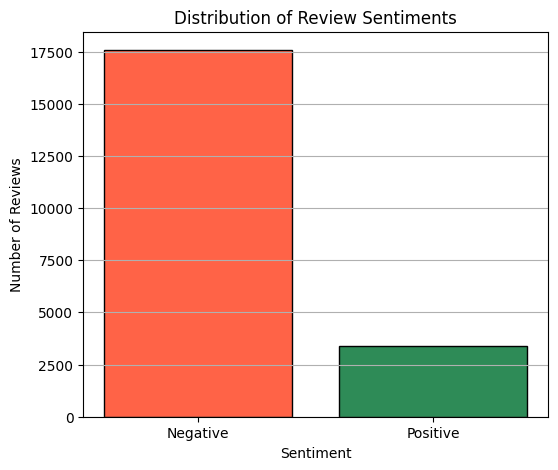

In [22]:
sentiment_counts = reviews_data["Sentiment"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    ["Negative", "Positive"],
    sentiment_counts.values,
    color=["tomato", "seagreen"],
    edgecolor="black"
)

plt.title("Distribution of Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.grid(axis="y")

plt.show()

# Text Preprocessing

Before training the model, the review text needs to be cleaned. In this step, unnecessary characters and common words are removed to prepare the text for sentiment analysis.

 1. Download NLTK Resources

We'll use the NLTK library to access resources such as stopwords, which help clean and preprocess the review text.

In [23]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

2. Import NLP Libraries

The required NLP libraries are imported to clean and preprocess the review text. These libraries help with tasks such as removing stopwords and stemming words before model training.

In [24]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import re
import string

3. Initialize Stopwords and Stemmer

The English stopwords list and Porter Stemmer are initialized before preprocessing the review text. These will be used to remove common words and reduce words to their root form.

In [25]:
stop_words = set(stopwords.words("english"))

stemmer = PorterStemmer()

 4. Create a Text Cleaning Function

A function is created to clean the review text before feature extraction. It performs the following preprocessing steps:

- Converts text to lowercase
- Removes HTML tags
- Removes punctuation
- Removes numbers
- Removes extra spaces
- Removes stopwords
- Applies stemming
- Applies stemming

In [26]:
def clean_review(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords and apply stemming
    words = []

    for word in text.split():

        if word not in stop_words:

            words.append(stemmer.stem(word))

    return " ".join(words)

5. Apply Text Cleaning

The text cleaning function is applied to each review in the dataset, and the cleaned text is stored in a new column called `Cleaned_Text`.

In [27]:
reviews_data["Cleaned_Text"] = reviews_data["Text"].apply(clean_review)

6. Compare Original and Cleaned Reviews

Let's compare the original and cleaned reviews to see how the preprocessing steps have changed the text.

In [28]:
reviews_data[["Text", "Cleaned_Text"]].head(10)

,Text,Cleaned_Text
6316,The Maxwell House International Coffee - Vanil...,maxwel hous intern coffe vanilla nut cafe abso...
19874,Now this is the way everyone should drink coff...,way everyon drink coffe pleas product coffe ev...
1638,A dream for those on Weight Watchers who love ...,dream weight watcher love potato chip individu...
4026,I have had to change my diet and now have bett...,chang diet better health tasti
260,"These are healthy and my mixed Llasa, Tibetan ...",healthi mix llasa tibetan terrier ador healthi...
18766,Celsius sparkling orange has a light carbonati...,celsiu sparkl orang light carbon light orang t...
5151,I live in the area where these cookies are mad...,live area cooki made rememb buy local coffe st...
2806,"When I first started to use IAMS Savory Sauce,...",first start use iam savori sauc dog love week ...
17027,"This coffee tastes great, a strong flavor with...",coffe tast great strong flavor without bitter ...
4538,"Melitta Cafe is a smooth, flavorful coffee tha...",melitta cafe smooth flavor coffe compar well r...


# Feature Extraction using TF-IDF

The cleaned reviews are converted into numerical features using the TF-IDF technique so they can be used for model training.

 1. Separate Input Features and Target Variable

The `Cleaned_Text` column is selected as the input feature (`X`), and the `Sentiment` column is used as the target variable (`y`).

In [29]:
# Input Feature
X = reviews_data["Cleaned_Text"]

# Target Variable
y = reviews_data["Sentiment"]

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)

Input Shape : (20961,)
Target Shape: (20961,)


2. Initialize TF-IDF Vectorizer

The TF-IDF Vectorizer is initialized to convert the cleaned reviews into numerical features for model training.

In [30]:
vectorizer = TfidfVectorizer(
    max_features=5000
)

3. Convert Text into TF-IDF Features

The TF-IDF Vectorizer is applied to the cleaned reviews to convert the text into numerical features for model training.

In [31]:
X = vectorizer.fit_transform(X)

4. Verify the Feature Matrix

Let's check the shape of the TF-IDF features to confirm the number of reviews and extracted features.

In [32]:
print("TF-IDF Feature Matrix Shape:")

print(X.shape)

TF-IDF Feature Matrix Shape:
(20961, 5000)


 5. Display Sample TF-IDF Features

Let's look at the first 20 TF-IDF features to see the words extracted from the cleaned reviews.

In [33]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:20])

['abandon' 'abil' 'abl' 'absolut' 'absorb' 'abuelita' 'abund' 'acacia'
 'acai' 'accent' 'accept' 'access' 'accid' 'accident' 'accompani'
 'accomplish' 'accord' 'account' 'accur' 'accustom']


6. Display a Sample of the TF-IDF Matrix

Let's display the TF-IDF features for the first five reviews to see how the text has been converted into numerical values.

In [34]:
X[:5]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 62 stored elements and shape (5, 5000)>

# Model Building

After preparing the data, the Logistic Regression model is trained to classify customer reviews as positive or negative.

 1. Split the Dataset

The dataset is split into training and testing sets.

- **80%** of the data is used to train the model.
- **20%** of the data is reserved to evaluate the model on unseen reviews.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

Training Features Shape : (16768, 5000)
Testing Features Shape  : (4193, 5000)
Training Labels Shape   : (16768,)
Testing Labels Shape    : (4193,)


2. Initialize the Logistic Regression Model

We'll initialize the Logistic Regression model, which will be used to classify reviews as positive or negative.

In [36]:
sentiment_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression Model Created Successfully.")

Logistic Regression Model Created Successfully.


 3. Train the Model

The Logistic Regression model is trained using the TF-IDF features from the training dataset.

In [37]:
sentiment_model.fit(X_train, y_train)

print("Model Trained Successfully.")

Model Trained Successfully.


4. Predict Review Sentiment

The trained model is used to predict the sentiment of the reviews in the testing dataset.

In [38]:
predicted_sentiment = sentiment_model.predict(X_test)

print("Prediction Completed Successfully.")

Prediction Completed Successfully.


 5. Compare Actual and Predicted Sentiments

Let's compare the actual and predicted sentiment labels for the first 10 reviews to see how the model performed.

In [39]:
comparison = pd.DataFrame({
    "Actual Sentiment": y_test.values,
    "Predicted Sentiment": predicted_sentiment
})

comparison.head(10)

,Actual Sentiment,Predicted Sentiment
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,0,1
6,0,0
7,0,1
8,1,1
9,1,1


# Model Evaluation

In this section, we'll evaluate the model's performance using different evaluation metrics.

 6. Calculate Accuracy

The accuracy score shows how many reviews were classified correctly by the model.

In [40]:
accuracy = accuracy_score(y_test, predicted_sentiment)

print("=" * 60)
print("MODEL ACCURACY")
print("=" * 60)

print(f"Accuracy: {accuracy:.4f}")

MODEL ACCURACY
Accuracy: 0.8994


7. Generate the Confusion Matrix

Let's generate the confusion matrix to see how well the model classified the test reviews.

In [41]:
conf_matrix = confusion_matrix(
    y_test,
    predicted_sentiment
)

print(conf_matrix)

[[ 328  362]
 [  60 3443]]


8. Classification Report

Let's generate the classification report to get a detailed view of the model's performance for each sentiment class.

In [42]:
print(classification_report(
    y_test,
    predicted_sentiment
))

              precision    recall  f1-score   support

           0       0.85      0.48      0.61       690
           1       0.90      0.98      0.94      3503

    accuracy                           0.90      4193
   macro avg       0.88      0.73      0.78      4193
weighted avg       0.90      0.90      0.89      4193



 9. Visualize the Confusion Matrix

Let's visualize the confusion matrix to see how well the model classified the test reviews.

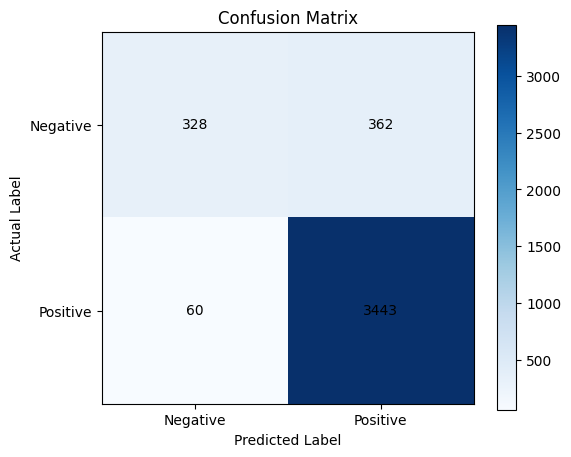

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(conf_matrix, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1], ["Negative", "Positive"])
plt.yticks([0,1], ["Negative", "Positive"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(
            j,
            i,
            conf_matrix[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.show()

# Data Visualization

The following visualizations help explore the review data and evaluate the performance of the sentiment analysis model.

 1. Review Score Distribution

Let's look at how customer reviews are distributed across the 1 to 5 star ratings.

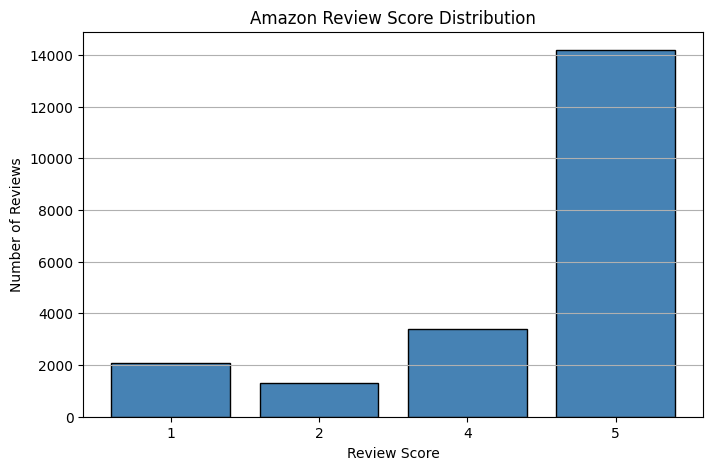

In [44]:
score_counts = reviews_data["Score"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    score_counts.index.astype(str),
    score_counts.values,
    color="steelblue",
    edgecolor="black"
)

plt.title("Amazon Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.grid(axis="y")

plt.show()

 2. Sentiment Distribution

Let's look at the distribution of positive and negative reviews in the dataset.

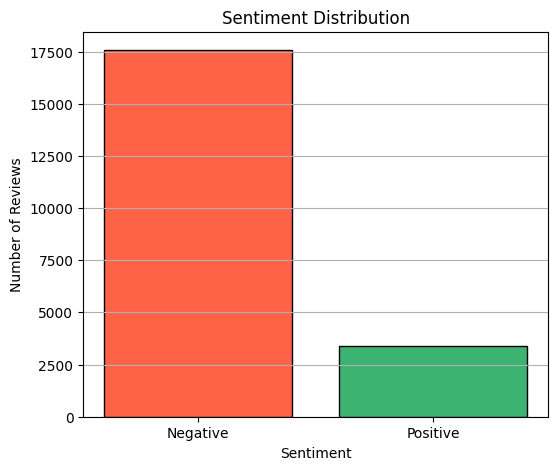

In [45]:
sentiment_counts = reviews_data["Sentiment"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    ["Negative","Positive"],
    sentiment_counts.values,
    color=["tomato","mediumseagreen"],
    edgecolor="black"
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.grid(axis="y")

plt.show()

 3. Top 20 Most Frequent Words

Let's look at the 20 most frequently used words in the cleaned reviews.

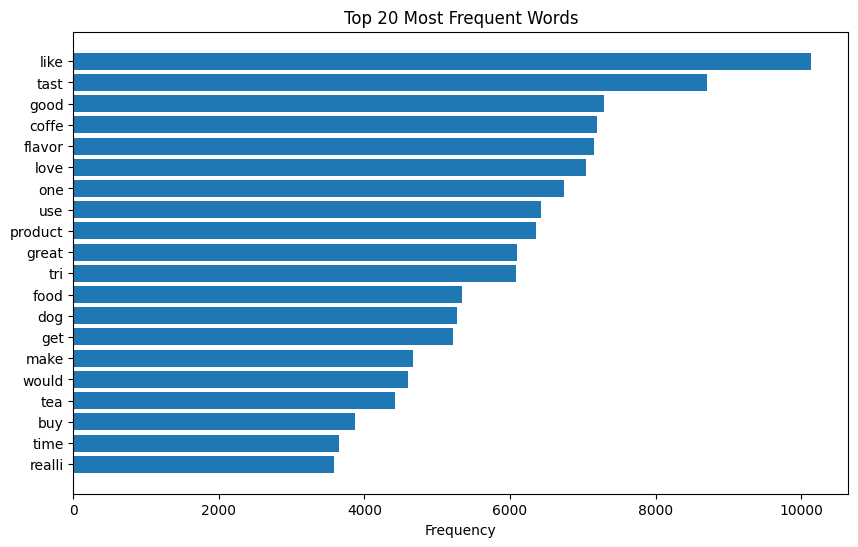

In [46]:
from collections import Counter

all_words = " ".join(reviews_data["Cleaned_Text"]).split()

word_counts = Counter(all_words)

top_words = word_counts.most_common(20)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10,6))

plt.barh(words, counts)

plt.title("Top 20 Most Frequent Words")

plt.xlabel("Frequency")

plt.gca().invert_yaxis()

plt.show()

 4. Most Frequent Words in Positive Reviews

Let's look at the 20 most frequently used words in positive reviews.

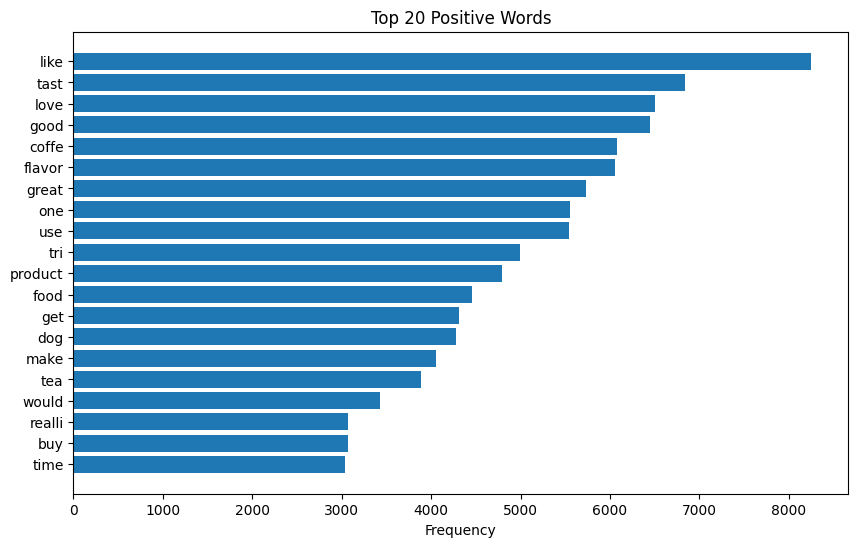

In [47]:
positive_reviews = reviews_data[
    reviews_data["Sentiment"] == 1
]

positive_words = " ".join(
    positive_reviews["Cleaned_Text"]
).split()

positive_counts = Counter(positive_words)

top_positive = positive_counts.most_common(20)

words = [word for word, count in top_positive]
counts = [count for word, count in top_positive]

plt.figure(figsize=(10,6))

plt.barh(words, counts)

plt.title("Top 20 Positive Words")

plt.xlabel("Frequency")

plt.gca().invert_yaxis()

plt.show()

 5. Most Frequent Words in Negative Reviews

The chart below shows the 20 most common words found in negative customer reviews.

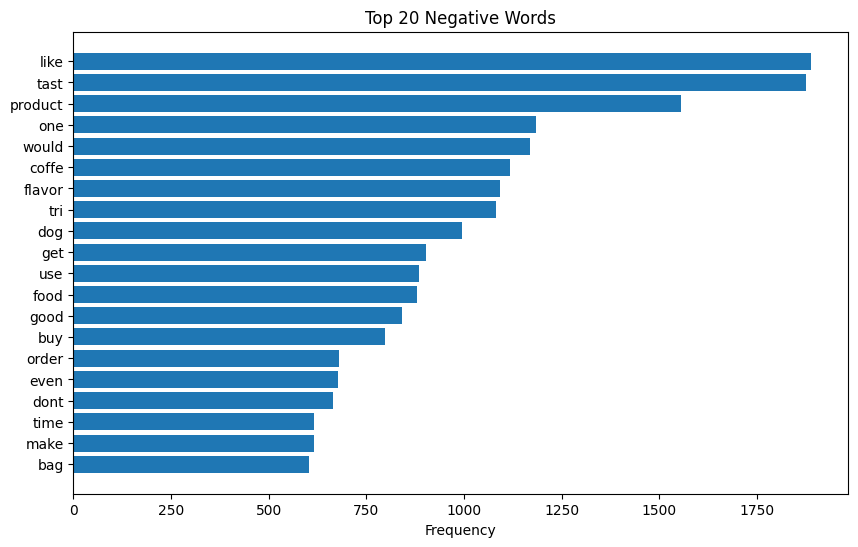

In [48]:
negative_reviews = reviews_data[
    reviews_data["Sentiment"] == 0
]

negative_words = " ".join(
    negative_reviews["Cleaned_Text"]
).split()

negative_counts = Counter(negative_words)

top_negative = negative_counts.most_common(20)

words = [word for word, count in top_negative]
counts = [count for word, count in top_negative]

plt.figure(figsize=(10,6))

plt.barh(words, counts)

plt.title("Top 20 Negative Words")

plt.xlabel("Frequency")

plt.gca().invert_yaxis()

plt.show()

# Predict Sentiment for a Custom Review

The trained model can be used to predict the sentiment of a new customer review entered by the user..

## Predict a Custom Amazon Review

A custom review is preprocessed, converted into TF-IDF features, and then classified as either **Positive** or **Negative** using the trained model.

In [49]:
custom_review = "This product is absolutely amazing. I really loved the quality and would definitely buy it again."

clean_review_text = clean_review(custom_review)

vectorized_review = vectorizer.transform([clean_review_text])

prediction = sentiment_model.predict(vectorized_review)

if prediction[0] == 1:
    print("Predicted Sentiment: Positive 😊")
else:
    print("Predicted Sentiment: Negative 😞")

Predicted Sentiment: Positive 😊


# Conclusion

In this project, an Amazon Product Review Sentiment Analysis model was built using NLP and machine learning techniques. The dataset was cleaned and preprocessed before converting the review text into numerical features using TF-IDF.

A Logistic Regression model was trained to classify reviews as positive or negative. The model was then evaluated using accuracy, a confusion matrix, and a classification report to measure its performance.

Overall, this project provided practical experience with text preprocessing, feature extraction, and sentiment classification using machine learning.

# Future Scope

This project can be improved in several ways:

- Compare the performance of other machine learning models such as Naive Bayes, Support Vector Machine (SVM), Random Forest, and XGBoost.
- Use deep learning models like LSTM or BERT to improve sentiment prediction.
- Develop a web application using Streamlit or Flask for real-time sentiment analysis.
- Extend the model to classify reviews into Positive, Neutral, and Negative categories instead of only two classes.

# References

- Amazon Fine Food Reviews Dataset (Kaggle)
- Python Documentation
- Pandas Documentation
- NumPy Documentation
- Matplotlib Documentation
- NLTK Documentation
- Scikit-learn Documentation